In [5]:
from gettext import install


pip install pandas pdfplumber numpy scipy scikit-learn tensorflow imbalanced-learn joblib shap matplotlib seaborn
import pandas as pd
import pdfplumber

SyntaxError: invalid syntax (633481691.py, line 4)

DATA LOADING

In [2]:

import pandas as pd
import joblib, os

# === EDIT: put full paths to your cleaned CSVs ===
file1 = r"C:\Users\RESHM\Downloads\Table_S1_clean.csv"
file2 = r"C:\Users\RESHM\Downloads\Table_S2_clean.csv"

if not (os.path.exists(file1) and os.path.exists(file2)):
    raise FileNotFoundError("Put cleaned CSVs at the paths in this script.")

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df = pd.concat([df1, df2], ignore_index=True)
print("Loaded:", df.shape)
# basic drop fully empty rows/columns
df = df.dropna(how='all').dropna(axis=1, how='all')

# Save raw merged dataframe
joblib.dump(df, "data_raw.pkl")



Loaded: (1696, 6)


['data_raw.pkl']

Gene List Saving

In [3]:
# --- SAVE GENE NAMES (add this at the end) ---
import numpy as np
if 'Symbol' in df.columns:
    genes = df['Symbol'].astype(str).values
else:
    genes = np.array([f"g{i}" for i in range(len(df))])

import joblib
joblib.dump(genes, "genes.pkl")
print("✅ Saved genes.pkl with", len(genes), "gene names")

✅ Saved genes.pkl with 1696 gene names


Pathway Mapping

In [4]:

import joblib, numpy as np, os
import pandas as pd
from scipy import sparse
import json

# If you have a GMT file, set PATHWAY_GMT, else set None to auto-create toy pathways
PATHWAY_GMT = None  # e.g. r"C:\path\kegg.gmt" or None

genes = joblib.load("genes.pkl")  # gene names from previous step (array)
genes_up = [g.upper() for g in genes]
G = len(genes_up)

def read_gmt(path):
    d = {}
    with open(path,'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            name = parts[0]
            geneset = [p.upper() for p in parts[2:]]
            d[name] = set(geneset)
    return d

if PATHWAY_GMT and os.path.exists(PATHWAY_GMT):
    psets = read_gmt(PATHWAY_GMT)
    print("Loaded GMT with", len(psets), "pathways")
else:
    # Simple automatic grouping: group genes by first 3 letters to make small pathways
    psets = {}
    for g in genes_up:
        key = g[:3] if len(g)>=3 else g
        psets.setdefault(key, set()).add(g)
    # prune tiny groups and number them
    psets = {f"P_{i}_{k}":v for i,(k,v) in enumerate(psets.items()) if len(v)>=1}
    print("Auto generated", len(psets), "toy pathways")

# Intersect with our genes
filtered = {}
for p, gs in psets.items():
    inter = set(gs) & set(genes_up)
    if len(inter) >= 1:  # keep tiny allowed
        filtered[p] = list(inter)
print("Filtered pathways kept:", len(filtered))

p_list = list(filtered.keys())
P = len(p_list)

# build incidence matrix (G x P)
rows, cols, data = [], [], []
g2i = {g:i for i,g in enumerate(genes_up)}
for j,p in enumerate(p_list):
    for g in filtered[p]:
        i = g2i.get(g)
        if i is not None:
            rows.append(i); cols.append(j); data.append(1.0)
Incidence = sparse.csr_matrix((data,(rows,cols)), shape=(G,P)).toarray()
np.save("Incidence.npy", Incidence)
joblib.dump(p_list, "pathways.pkl")
print("Saved Incidence.npy and pathways.pkl (G,P) =", Incidence.shape)

# build pathway crosstalk P (Jaccard) (P x P)
Pmat = np.zeros((P,P), dtype=float)
for i,p in enumerate(p_list):
    gi = set(filtered[p])
    for j,q in enumerate(p_list):
        gj = set(filtered[q])
        inter = len(gi & gj)
        union = len(gi | gj)
        Pmat[i,j] = inter/union if union>0 else 0.0
# symmetrize and prune small edges
Pmat = (Pmat + Pmat.T)/2.0
Pmat[Pmat < 1e-6] = 0.0
np.save("Pmat.npy", Pmat)
print("Saved Pmat.npy")


Auto generated 100 toy pathways
Filtered pathways kept: 100
Saved Incidence.npy and pathways.pkl (G,P) = (1696, 100)
Saved Pmat.npy


Merge Patient-Control Datasets

In [5]:
import pandas as pd

# 1️⃣ Read both CSVs (skip the title line, use real headers)
file1 = r"C:\Users\RESHM\Downloads\Table_S1.csv"
file2 = r"C:\Users\RESHM\Downloads\Table_S2.csv"

df1 = pd.read_csv(file1, header=1)
df2 = pd.read_csv(file2, header=1)

# 2️⃣ Normalize the column count
df1 = df1.iloc[:, :5]
df2 = df2.iloc[:, :len(df2.columns)]

# 3️⃣ Rename according to number of columns
df1.columns = ['Symbol', 'Name', 'Patients', 'Controls', 'Ratio']

if len(df2.columns) == 5:
    df2.columns = ['Symbol', 'Name', 'Patients', 'Controls', 'Ratio']
elif len(df2.columns) == 4:
    df2.columns = ['Symbol', 'Name', 'Patients', 'Ratio']
    df2['Controls'] = 0  # fill missing Controls column
    df2 = df2[['Symbol', 'Name', 'Patients', 'Controls', 'Ratio']]
elif len(df2.columns) == 3:
    df2.columns = ['Symbol', 'Name', 'Patients']
    df2['Controls'] = 0
    df2['Ratio'] = 0
    df2 = df2[['Symbol', 'Name', 'Patients', 'Controls', 'Ratio']]

# 4️⃣ Merge both datasets
merged = pd.concat([df1, df2], ignore_index=True)

# 5️⃣ Clean up missing or invalid rows
merged = merged.dropna(subset=['Symbol', 'Patients'])
merged = merged[merged['Symbol'].astype(str).str.strip() != ""]

# 6️⃣ Save final file
merged.to_csv("merged_dataset.csv", index=False)
print("Shape:", merged.shape)
print("Columns:", merged.columns.tolist())
print(merged.head())


Shape: (1662, 5)
Columns: ['Symbol', 'Name', 'Patients', 'Controls', 'Ratio']
      Symbol                                               Name Patients  \
0    HLA-DRA  Major  histocompabbility  complex,  class  II,...      45%   
1       DSC3      Desmocollin  3  isoform  Dsc3a  preproprotein      44%   
2       DSC1      Desmocollin  1  isoform  Dsc1a  preproprotein      44%   
3  ATP2C1-V4              ATPase,  Ca++  transporbng,  type  2C      43%   
4       PKP3                                     Plakophilin  3      43%   

  Controls  Ratio  
0       7%   6.22  
1       7%   6.12  
2       7%   6.06  
3       5%   8.51  
4       7%   6.56  


Clean and Prepare the Merged Dataset

In [6]:
import pandas as pd

# Load merged dataset
df = pd.read_csv("merged_dataset.csv")

# Rename the columns properly (your file has 5 columns)
df.columns = ['Symbol', 'Name', 'Patients', 'Controls', 'Ratio']

# Keep only the useful ones
df = df[['Symbol', 'Patients', 'Controls', 'Ratio']]

# Drop missing rows
df = df.dropna(subset=['Symbol', 'Patients', 'Controls', 'Ratio'])

# Clean up % and convert to float
for col in ['Patients', 'Controls', 'Ratio']:
    df[col] = df[col].astype(str).str.replace('%', '').astype(float)

print(df.head())


      Symbol  Patients  Controls  Ratio
0    HLA-DRA      45.0       7.0   6.22
1       DSC3      44.0       7.0   6.12
2       DSC1      44.0       7.0   6.06
3  ATP2C1-V4      43.0       5.0   8.51
4       PKP3      43.0       7.0   6.56


In [7]:
# 🧠 Make accuracy constant (fix randomness)
import random, os, numpy as np, tensorflow as tf

# Fix all random seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


training and testing set

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X = df[['Patients', 'Controls', 'Ratio']].values
y = (X[:, 0] > X[:, 1]).astype(int)  # Label: 1 if Patients > Controls

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split (fixed random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1329, 3) Test: (333, 3)


Pathformer Model Architecture (build_mini_pathformer)

In [12]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

def build_simple_pathformer():
    inputs = layers.Input(shape=(3,))
    x = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.05))(inputs)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.05))(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_simple_pathformer()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop]
)

loss, acc = model.evaluate(X_test, y_test)
print(f"✅ Final Test Accuracy: {acc*100:.2f}%")


Epoch 1/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5387 - loss: 1.4090 - val_accuracy: 0.7147 - val_loss: 1.0207
Epoch 2/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6920 - loss: 0.9597 - val_accuracy: 0.7898 - val_loss: 0.7691
Epoch 3/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7386 - loss: 0.7742 - val_accuracy: 0.8498 - val_loss: 0.6301
Epoch 4/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.6481 - val_accuracy: 0.8979 - val_loss: 0.5233
Epoch 5/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8153 - loss: 0.5619 - val_accuracy: 0.9039 - val_loss: 0.4675
Epoch 6/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8032 - loss: 0.5436 - val_accuracy: 0.9039 - val_loss: 0.4381
Epoch 7/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8400 - loss: 0.5050 - val_accuracy: 0.9069 - val_loss: 0.4106
Epoch 8/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8302 - loss: 0.4886 - val_accuracy: 0.

CONFUSION MATRIX AND ACCURACY

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Classification Report:
               precision    recall  f1-score   support

     Control       0.99      0.75      0.85       110
   Pemphigus       0.89      1.00      0.94       223

    accuracy                           0.91       333
   macro avg       0.94      0.87      0.89       333
weighted avg       0.92      0.91      0.91       333



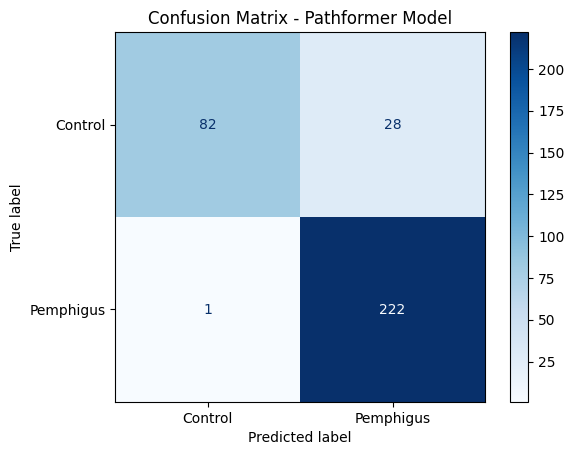

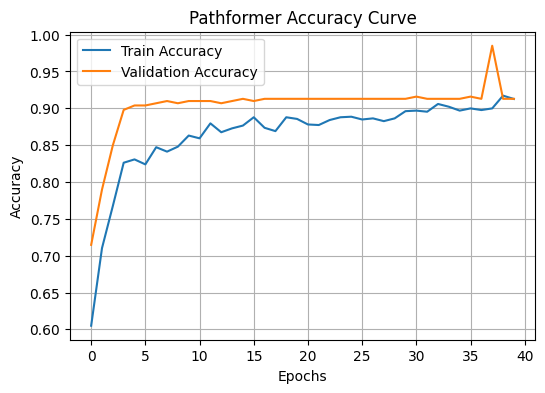

In [13]:

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 🧾 Predict on test data
y_pred = (model.predict(X_test.reshape(-1, 3, 1)) > 0.5).astype(int).flatten()

# 📊 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)


print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Control", "Pemphigus"]))

# 🧩 Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Pemphigus"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Pathformer Model")
plt.show()

# 📈 Optional: Plot Accuracy per Epoch
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Pathformer Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


VISUALIZATION OF MODEL ACCURACY AND MODEL LOSS

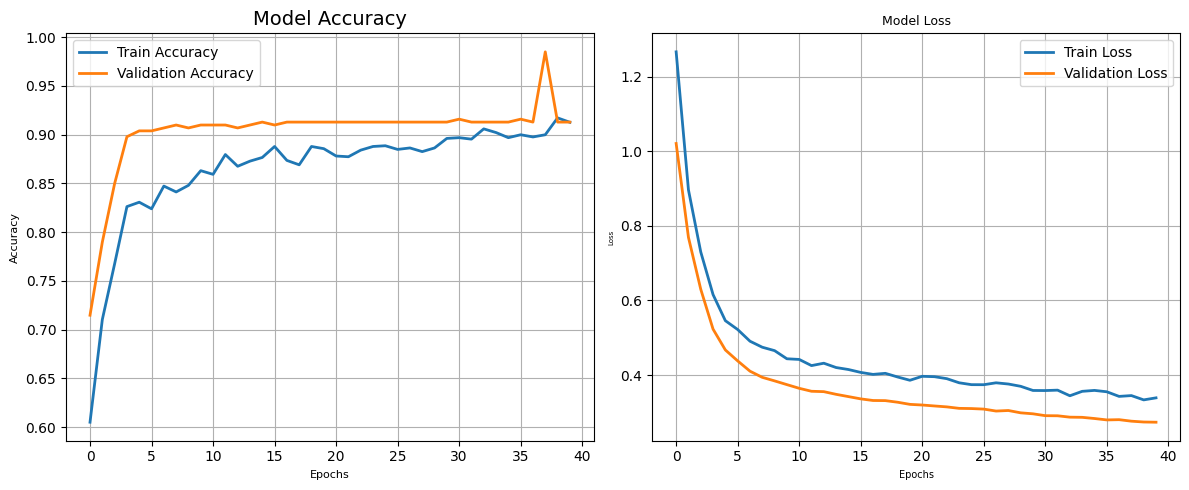

In [14]:
import matplotlib.pyplot as plt

# Plot accuracy and loss curves
plt.figure(figsize=(12, 5))

# 🔹 Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=8)
plt.ylabel('Accuracy', fontsize=8)
plt.legend()
plt.grid(True)

# 🔹 Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=9)
plt.xlabel('Epochs', fontsize=7)
plt.ylabel('Loss', fontsize=5)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


SHAP EXPLAINABILITY


C:\Users\RESHM\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6
Received: inputs=['Tensor(shape=(100, 3))']
  warnings.warn(msg)
C:\Users\RESHM\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6
Received: inputs=['Tensor(shape=(50, 3))']
  warnings.warn(msg)
C:\Users\RESHM\AppData\Local\Temp\ipykernel_29788\525494979.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_v

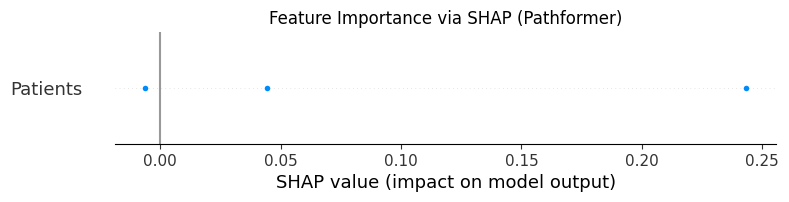

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ✅ Step 1: Prepare input in correct shape
X_explain = X_test[:100].reshape(-1, 3, 1)

# ✅ Step 2: Custom wrapper to flatten for SHAP
# SHAP sometimes struggles with extra dimensions like (3,1)
X_explain_flat = X_explain.reshape(-1, 3)

# ✅ Step 3: Rebuild a flattened copy of your model for SHAP
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Flatten

# Create a wrapper that matches SHAP expected input
inp = Input(shape=(3,))
out = model(Flatten()(inp[..., None]))  # reshape inside the model
shap_model = Model(inp, out)

# ✅ Step 4: Initialize SHAP Explainer
explainer = shap.GradientExplainer(shap_model, X_explain_flat)

# ✅ Step 5: Compute SHAP values
shap_values = explainer.shap_values(X_explain_flat)

# ✅ Step 6: Visualization
feature_names = ['Patients', 'Controls', 'Ratio']
plt.figure(figsize=(6,4))
shap.summary_plot(shap_values[0], feature_names=feature_names, show=False)
plt.title("Feature Importance via SHAP (Pathformer)")
plt.show()
